In [ ]:
# calculator of greeks
# https://www.tradingblock.com/calculators/option-greeks-calculator using these as inspiracion

# S = Current stock price
# K = Strike price
# T = Time to expiration (in years)
# r = Risk free rate
# σ = Volatility of the underlying asset
# N(d) = Cumulative distribution function (CDF) of the standard normal distribution
# N'(d) = Probability density function (PDF) of the standard normal distribution

In [1]:
import pandas as pd
import numpy as np
from scipy.stats import norm
import math
import matplotlib.pyplot as plt

In [2]:
params = {"S": 100, "K": 100, "T": 30, "r": 0.035, "o": 0.2}

In [3]:
S = params["S"]
K = params["K"]
T = params["T"]
r = params["r"]
o = params["o"]

Option Delta Calculation
For Call Options:
Delta = N(d1)

For Put Options:
Delta = N(d1) - 1
d1 = [ln(S/K) + (r + σ²/2) * T] / (σ * √T)

In [4]:
def calculate_delta(call=True, **kwargs):

    S = kwargs.get("S")
    K = kwargs.get("K")
    r = kwargs.get("r")
    T = kwargs.get("T")
    o = kwargs.get("o")

    d1 = (math.log(S / K) + (r + o**2 / 2) * T) / (o * math.sqrt(T))

    if call:
        delta = norm.cdf(d1)
    else:
        delta = norm.cdf(d1) - 1

    return delta


calculate_delta(**params)

0.9339968320908162

Option Gamma Calculation
Gamma = N'(d1) / (S * σ * √T)

In [5]:
def calculate_gamma(**kwargs):

    S = kwargs.get("S")
    K = kwargs.get("K")
    r = kwargs.get("r")
    T = kwargs.get("T")
    o = kwargs.get("o")

    d1 = (math.log(S / K) + (r + (o**2) / 2) * T) / (o * math.sqrt(T))

    gamma = norm.pdf(d1) / (S * o * math.sqrt(T))

    return gamma


calculate_gamma(**params)

0.0011712959453162898

Option Theta Calculation
For Call Options:
Theta = [-S * N'(d1) * σ / (2 * √T)] - [r * K * e^(-rT) * N(d2)]

For Put Options:
Theta = [-S * N'(d1) * σ / (2 * √T)] + [r * K * e^(-rT) * N(-d2)]

d2 = d1 - σ * √T

In [6]:
def calculate_theta(call=True, **kwargs):

    S = kwargs.get("S")
    K = kwargs.get("K")
    r = kwargs.get("r")
    T = kwargs.get("T")
    o = kwargs.get("o")

    d1 = (math.log(S / K) + (r + (o**2) / 2) * T) / (o * math.sqrt(T))
    d2 = d1 - o * math.sqrt(T)

    if call:
        theta = (-S * norm.pdf(d1) * o / (2 * math.sqrt(T))) - (
            r * K * math.exp(-r * T) * norm.cdf(d2)
        )
    else:
        theta = (-S * norm.pdf(d1) * o / (2 * math.sqrt(T))) + (
            r * K * math.exp(-r * T) * norm.cdf(-d2)
        )

    return theta


calculate_theta(**params)

-1.0418651370908627

Option Vega Calculation
Vega = S * N'(d1) * √T

In [7]:
def calculate_vega(**kwargs):

    S = kwargs.get("S")
    K = kwargs.get("K")
    r = kwargs.get("r")
    T = kwargs.get("T")
    o = kwargs.get("o")

    d1 = (math.log(S / K) + (r + (o**2) / 2) * T) / (o * math.sqrt(T))

    vega = S * norm.pdf(d1) * math.sqrt(T)

    return vega


calculate_vega(**params)

70.27775671897739

Option Rho Calculation
For Call Options:

Rho = K * T * e^(-rT) * N(d2)

For Put Options:‍

Rho = -K * T * e^(-rT) * N(-d2)

In [8]:
def calculate_rho(call=True, **kwargs):

    S = kwargs.get("S")
    K = kwargs.get("K")
    r = kwargs.get("r")
    T = kwargs.get("T")
    o = kwargs.get("o")

    d1 = (math.log(S / K) + (r + (o**2) / 2) * T) / (o * math.sqrt(T))
    d2 = d1 - o * math.sqrt(T)

    if call:
        rho = K * T * math.exp(-r * T) * norm.cdf(d2)
    else:
        rho = -K * T * math.exp(-r * T) * norm.cdf(-d2)

    return rho


calculate_rho(**params)

692.2336697379469

In [9]:
def calculate_greeks(call=True, **kwargs):

    delta = calculate_delta(call=call, **kwargs)
    gamma = calculate_gamma(**kwargs)
    theta = calculate_theta(call=call, **kwargs)
    vega = calculate_vega(**kwargs)
    rho = calculate_rho(call=call, **kwargs)

    greeks = {"delta": delta, "gamma": gamma, "theta": theta, "vega": vega, "rho": rho}

    for k in greeks:
        print(f"{k} is equal to {greeks[k]} ")

In [10]:
calculate_greeks(**params)

delta is equal to 0.9339968320908162 
gamma is equal to 0.0011712959453162898 
theta is equal to -1.0418651370908627 
vega is equal to 70.27775671897739 
rho is equal to 692.2336697379469 


In [11]:
class BlackScholes:
    def __init__(self, S, K, T, r, o, call=True):

        self.S = S
        self.K = K
        self.T = T / 365
        self.r = r
        self.o = o
        self.call = call

        self.d1 = (math.log(S / K) + (r + (o**2) / 2) * self.T) / (
            o * math.sqrt(self.T)
        )
        self.d2 = self.d1 - o * math.sqrt(self.T)
        self.disc = math.exp(-r * self.T)

    def delta(self):
        if self.call:
            return norm.cdf(self.d1)
        return norm.cdf(self.d1) - 1

    def gamma(self):
        return norm.pdf(self.d1) / (self.S * self.o * math.sqrt(self.T))

    def theta(self):
        base = -self.S * norm.pdf(self.d1) * self.o / (2 * math.sqrt(self.T))
        if self.call:
            return base - (
                self.r * self.K * math.exp(-self.r * self.T) * norm.cdf(self.d2)
            )
        return base + (
            self.r * self.K * math.exp(-self.r * self.T) * norm.cdf(-self.d2)
        )

    def vega(self):
        return self.S * norm.pdf(self.d1) * math.sqrt(self.T)

    def rho(self):
        if self.call:
            return self.K * self.T * math.exp(-self.r * self.T) * norm.cdf(self.d2)
        return -self.K * self.T * math.exp(-self.r * self.T) * norm.cdf(-self.d2)

    def price(self):
        if self.call:
            return self.S * norm.cdf(self.d1) - self.K * self.disc * norm.cdf(self.d2)
        return self.K * self.disc * norm.cdf(-self.d2) - self.S * norm.cdf(-self.d1)

    def bid_ask(self, spread=0.05):
        mid = self.price()
        return {"mid": mid, "bid": mid - spread / 2, "ask": mid + spread / 2}

    def greeks(self):
        return {
            "delta": self.delta(),
            "gamma": self.gamma(),
            "theta": self.theta(),
            "vega": self.vega(),
            "rho": self.rho(),
        }

    def opcion_chain_values(self):
        return {
            "delta": self.delta(),
            "gamma": self.gamma(),
            "theta": self.theta(),
            "vega": self.vega(),
            "bid": self.bid_ask()["bid"],
            "ask": self.bid_ask()["ask"],
        }

In [12]:
f1 = BlackScholes(**params)
f1.greeks()

{'delta': 0.5314200759098613,
 'gamma': 0.06936112703972908,
 'theta': -15.647132809761368,
 'vega': 11.401829102421217,
 'rho': 4.168080004263527}

Prices call 

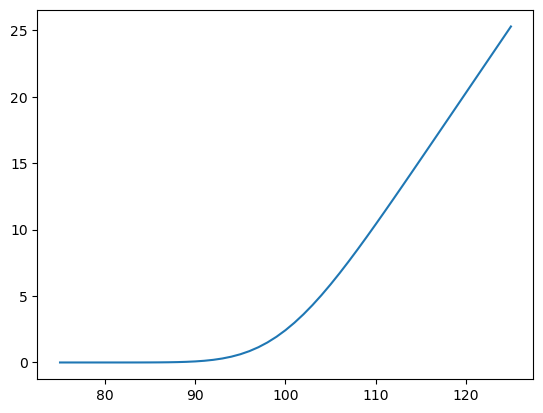

In [13]:
Ks = np.linspace(75, 125, 51)

prices = []

for i in range(len(Ks)):
    bs_call = BlackScholes(Ks[i], 100, 30, 0.035, 0.2, call=True)
    prices.append(bs_call.price())

plt.plot(Ks, prices)

Prices put


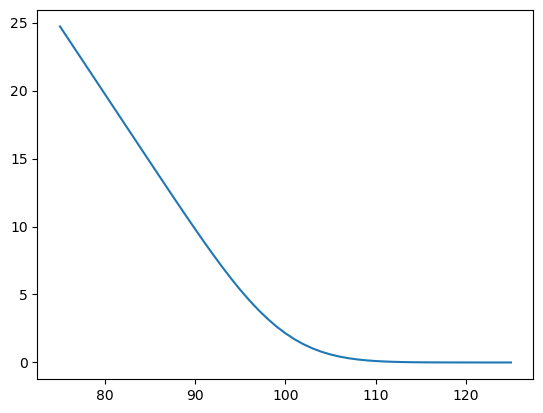

In [14]:
Ks = np.linspace(75, 125, 51)

prices = []

for i in range(len(Ks)):
    bs_call = BlackScholes(Ks[i], 100, 30, 0.035, 0.2, call=False)
    prices.append(bs_call.price())

plt.plot(Ks, prices)

Time decay

/var/folders/hb/3snbzqyx6yd_96gxhv_h781w0000gn/T/ipykernel_14387/1920952234.py:11: RuntimeWarning: invalid value encountered in scalar divide
  self.d1 = (math.log(S/K) + (r + (o**2)/2) * self.T)/ (o * math.sqrt(self.T))


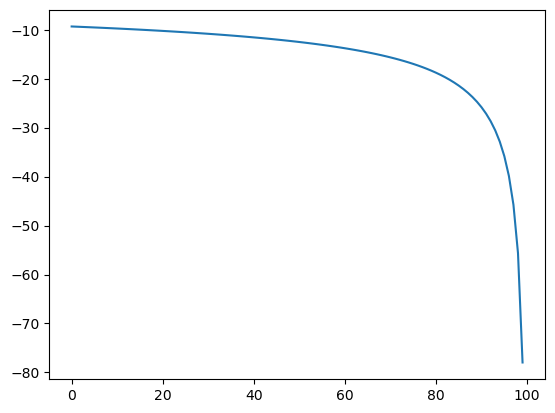

In [15]:
days = np.linspace(0, 100, 101)

Thetas = []

for i in range(len(days)):
    val = BlackScholes(100, 100, days[i], 0.035, 0.2, call=True)
    Thetas.append(val.theta())

plt.plot(days[::-1], Thetas)

Delta vs Gamma

Text(0.5, 1.0, 'Delta = speed |  Gamma = acceleration')

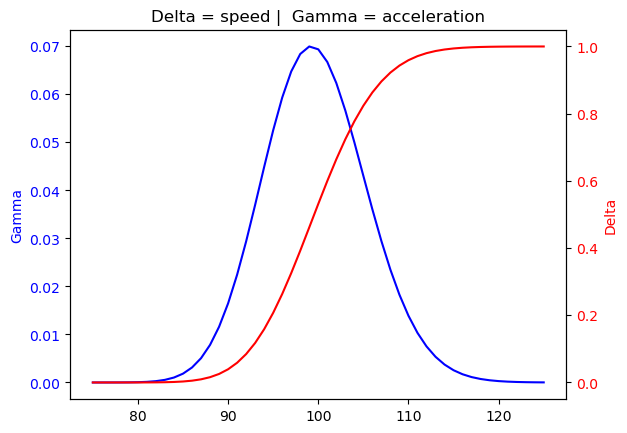

In [16]:
Ks = np.linspace(75, 125, 51)

Deltas = []
Gammas = []

for i in range(len(Ks)):
    bs_call = BlackScholes(Ks[i], 100, 30, 0.035, 0.2, call=True)
    Deltas.append(bs_call.delta())

for i in range(len(Ks)):
    bs_call = BlackScholes(Ks[i], 100, 30, 0.035, 0.2, call=True)
    Gammas.append(bs_call.gamma())

fig, ax1 = plt.subplots()

# Left axis
ax1.plot(Ks, Gammas, "b-", label="Gamma")
ax1.set_ylabel("Gamma", color="b")
ax1.tick_params(axis="y", labelcolor="b")

# Right axis
ax2 = ax1.twinx()
ax2.plot(Ks, Deltas, "r-", label="Delta")
ax2.set_ylabel("Delta", color="r")
ax2.tick_params(axis="y", labelcolor="r")

plt.title("Delta = speed |  Gamma = acceleration")

In [ ]:
S = 63
Ks = np.linspace(int(S * 3 / 4), int(S * 5 / 4), int(S * 1 / 2) + 1)
Ks

In [17]:
def opcion_chain(S, K, T, r, o, spacing=2.5):

    Ks = np.linspace(K - spacing * 5, K + spacing * 5, 11)
    call_vals = [
        BlackScholes(S, k, T, r, o, call=True).opcion_chain_values() for k in Ks
    ]
    df_calls = pd.DataFrame(call_vals, index=Ks.round(1))
    df_calls["strike"] = Ks

    put_vals = [
        BlackScholes(S, k, T, r, o, call=False).opcion_chain_values() for k in Ks
    ]
    df_puts = pd.DataFrame(put_vals, index=Ks.round(1))
    df_puts = df_puts[df_puts.columns[::-1]]

    chain = pd.concat([df_calls, df_puts], axis=1)

    return chain

In [18]:
chain = opcion_chain(100, 100, 30, 0.035, 0.2)
print(chain)

          delta     gamma      theta       vega        bid        ask  strike  \
87.5   0.991973  0.003834  -3.791918   0.630291  12.741864  12.791864    87.5   
90.0   0.972341  0.011092  -5.260329   1.823305  10.295503  10.345503    90.0   
92.5   0.924857  0.024724  -7.903046   4.064188   7.938236   7.988236    92.5   
95.0   0.834826  0.043322 -11.383740   7.121468   5.763735   5.813735    95.0   
97.5   0.698605  0.060766 -14.461377   9.988932   3.887601   3.937601    97.5   
100.0  0.531420  0.069361 -15.647133  11.401829   2.405368   2.455368   100.0   
102.5  0.362491  0.065402 -14.300958  10.750982   1.349922   1.399922   102.5   
105.0  0.220034  0.051644 -11.074353   8.489490   0.679153   0.729153   105.0   
107.5  0.118512  0.034582  -7.319774   5.684690   0.300426   0.350426   107.5   
110.0  0.056665  0.019863  -4.166139   3.265117   0.110603   0.160603   110.0   
112.5  0.024115  0.009889  -2.060470   1.625633   0.025995   0.075995   112.5   

             ask        bid

In [ ]:
from Functions import get_prices_opcions
import os
from dotenv import load_dotenv

load_dotenv()
ALPACA_KEY = st.secrets.get("ALPACA_KEY") or os.getenv("ALPACA_KEY")
ALPACA_SECRET = st.secrets.get("ALPACA_SECRET") or os.getenv("ALPACA_SECRET")

get_prices_opcions("AAPL")